In [1]:
import pandas
import requests
import sqlite3
import matplotlib
import re
print("Alt OK!")

Alt OK!


In [2]:
import bs4
print("BeautifulSoup OK!")

BeautifulSoup OK!


In [10]:
import requests

url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"

params ={
    "vs_currency": "usd",
    "days": "14",
    "interval": "daily"
}

response = requests.get(url, params=params)
print(response.json().keys())
print(response.status_code)

dict_keys(['prices', 'market_caps', 'total_volumes'])
200


In [11]:
data = response.json()
print(data["prices"][:3])

[[1779062400000, 77425.71519168488], [1779148800000, 76952.2148594993], [1779235200000, 76808.8105527178]]


In [12]:
prices_df = pandas.DataFrame(data["prices"], columns=["timestamp", "price"])
print(prices_df.head())

       timestamp         price
0  1779062400000  77425.715192
1  1779148800000  76952.214859
2  1779235200000  76808.810553
3  1779321600000  77459.944346
4  1779408000000  77546.337653


In [13]:
volumes_df = pandas.DataFrame(data["total_volumes"], columns=["timestamp", "volume"])
print(volumes_df.head())

       timestamp        volume
0  1779062400000  2.298513e+10
1  1779148800000  4.360067e+10
2  1779235200000  2.889639e+10
3  1779321600000  2.863719e+10
4  1779408000000  2.907525e+10


In [14]:
bitcoin_df = prices_df.merge(volumes_df, on="timestamp")

bitcoin_df['coin_id'] = "bitcoin"
print(bitcoin_df.head())

       timestamp         price        volume  coin_id
0  1779062400000  77425.715192  2.298513e+10  bitcoin
1  1779148800000  76952.214859  4.360067e+10  bitcoin
2  1779235200000  76808.810553  2.889639e+10  bitcoin
3  1779321600000  77459.944346  2.863719e+10  bitcoin
4  1779408000000  77546.337653  2.907525e+10  bitcoin


In [ ]:
def fetch_coin_data(coin):
    url = f"https://api.coingecko.com/api/v3/coins/{coin}/market_chart"
    params ={
        "vs_currency": "usd",
        "days": "14",
        "interval": "daily"
    }
    response = requests.get(url, params=params)
    data = response.json()
    
    prices_df = pandas.DataFrame(data["prices"], columns=["timestamp", "price"])
    volumes_df = pandas.DataFrame(data["total_volumes"], columns=["timestamp", "volume"])
    
    coin_df = prices_df.merge(volumes_df, on="timestamp")
    coin_df['coin_id'] = coin
    
    return coin_df

In [18]:
bitcoin_df = fetch_coin_data("bitcoin")
print(bitcoin_df.head())

       timestamp         price        volume  coin_id
0  1779062400000  77425.715192  2.298513e+10  bitcoin
1  1779148800000  76952.214859  4.360067e+10  bitcoin
2  1779235200000  76808.810553  2.889639e+10  bitcoin
3  1779321600000  77459.944346  2.863719e+10  bitcoin
4  1779408000000  77546.337653  2.907525e+10  bitcoin


In [19]:
ethereum_df = fetch_coin_data("ethereum")
solana_df = fetch_coin_data("solana")

all_coins_df = pandas.concat([bitcoin_df, ethereum_df, solana_df], ignore_index=True)
print(all_coins_df.head())
print(all_coins_df.tail())

       timestamp         price        volume  coin_id
0  1779062400000  77425.715192  2.298513e+10  bitcoin
1  1779148800000  76952.214859  4.360067e+10  bitcoin
2  1779235200000  76808.810553  2.889639e+10  bitcoin
3  1779321600000  77459.944346  2.863719e+10  bitcoin
4  1779408000000  77546.337653  2.907525e+10  bitcoin
        timestamp      price        volume coin_id
40  1779926400000  82.300658  2.539712e+09  solana
41  1780012800000  81.927343  2.925144e+09  solana
42  1780099200000  81.938250  2.417074e+09  solana
43  1780185600000  82.537048  1.395937e+09  solana
44  1780242116000  82.065652  1.312111e+09  solana


In [20]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

response = requests.get("https://www.coinmarketcap.com/", headers=headers)
print(response.status_code)
print(len(response.text))

200
695467


In [21]:
from bs4 import BeautifulSoup
soup = BeautifulSoup(response.text, "html.parser")
rows = soup.find_all("tr")
print(f"Fant {len(rows)} rader i tabellen.")
if rows:
    print("Første rad:")
    print(rows[0].text.strip())

Fant 102 rader i tabellen.
Første rad:
#NamePrice 1h %24h %7d %Market CapVolume(24h)Circulating SupplyLast 7 Days


In [22]:
print(rows[1].text.strip())

CoinMarketCap 20 Index DTFCMC20$149.440.12%0.14%3.00%$15.01M$15,011,971$3,639,06124.34K100.44K CMC20


In [23]:
print(rows[1].prettify()[:2000])

<tr style="cursor:pointer;background-color:var(--c-color-gray-100)">
 <td style="background-color:var(--c-color-gray-100)">
  <div class="BasePopover_base__T5yOf popover-base">
   <svg class="sc-c1554bc0-0 iSBlZT c-i" decode="async" height="1em" loading="lazy" priority="low" version="1.1" viewbox="0 0 24 24" width="1em" xmlns="http://www.w3.org/2000/svg">
    <use href="#star">
    </use>
   </svg>
  </div>
 </td>
 <td style="text-align:start;background-color:var(--c-color-gray-100)">
  <p class="sc-71024e3e-0 jBOvmG" color="text2" data-sensors-click="true" font-size="14">
   <svg class="sc-c1554bc0-0 euzJkK c-i" decode="async" height="1em" loading="lazy" priority="low" version="1.1" viewbox="0 0 24 24" width="1em" xmlns="http://www.w3.org/2000/svg">
    <use href="#announcement">
    </use>
   </svg>
  </p>
 </td>
 <td style="text-align:start;background-color:var(--c-color-gray-100)">
  <div class="sc-4c05d6ef-0 fmdKtv" display="flex">
   <a class="cmc-link" href="/currencies/coinmark

In [24]:
print(rows[1].find("p", class_="coin-item-name"))

<p class="sc-c1554bc0-0 eWrlhi coin-item-name">CoinMarketCap 20 Index DTF</p>


In [25]:
print(rows[1].find("p", class_="coin-item-symbol"))

<p class="sc-c1554bc0-0 gOVMPU coin-item-symbol">CMC20</p>


In [26]:
tds = rows[1].find_all("td")
for i, td in enumerate(tds):
    print(f"TD {i}: {td.text.strip()[:50]}")

TD 0: 
TD 1: 
TD 2: CoinMarketCap 20 Index DTFCMC20
TD 3: $149.44
TD 4: 0.12%
TD 5: 0.14%
TD 6: 3.00%
TD 7: $15.01M$15,011,971
TD 8: $3,639,06124.34K
TD 9: 100.44K CMC20
TD 10: 


In [35]:
crypto_list = []
for row in rows[1:16]:  # Hopp over header-raden
    name_tag = row.find("p", class_="coin-item-name")
    symbol_tag = row.find("p", class_="coin-item-symbol")
    tds = row.find_all("td")

    if name_tag and symbol_tag and len(tds) >= 6:
        crypto_list.append({
            "name": name_tag.text.strip(),
            "symbol": symbol_tag.text.strip(),
            "price": tds[3].text.strip(),
            "7d_change": tds[6].text.strip(),
        })

In [37]:
scraped_df = pandas.DataFrame(crypto_list)
print(scraped_df)

                          name symbol       price 7d_change
0   CoinMarketCap 20 Index DTF  CMC20     $149.44     3.00%
1                      Bitcoin    BTC  $73,553.44     3.62%
2                     Ethereum    ETH   $2,008.42     4.07%
3                       Tether   USDT     $0.9985     0.01%
4                          BNB    BNB     $718.96     9.78%
5                          XRP    XRP       $1.32     1.35%
6                         USDC   USDC     $0.9996     0.01%
7                       Solana    SOL      $81.95     3.84%
8                         TRON    TRX     $0.3482     4.68%
9                  Hyperliquid   HYPE      $68.28     7.22%
10                    Dogecoin   DOGE    $0.09993     1.90%
11                UNUS SED LEO    LEO      $10.01     0.21%
12                       Zcash    ZEC     $552.16    16.42%
13                     Cardano    ADA     $0.2341     3.56%
14                     Stellar    XLM     $0.2490    69.54%


In [41]:
scraped_df["7d_change"] = scraped_df["7d_change"].str.replace("%", "").str.strip().astype(float)

AttributeError: Can only use .str accessor with string values!

In [42]:
print(scraped_df.dtypes)
print(scraped_df["7d_change"].head())

name          object
symbol        object
price         object
7d_change    float64
dtype: object
0    3.00
1    3.62
2    4.07
3    0.01
4    9.78
Name: 7d_change, dtype: float64


In [46]:
scraped_df["price"] = scraped_df["price"].str.replace("$", "").str.replace(",", "").str.strip().astype(float)
print(scraped_df.dtypes)
print(scraped_df["price"].head())

name          object
symbol        object
price        float64
7d_change    float64
dtype: object
0      149.4400
1    73553.4400
2     2008.4200
3        0.9985
4      718.9600
Name: price, dtype: float64


In [ ]:
all_coins_df["date"] = pandas.to_datetime(all_coins_df["timestamp"], unit='ms').dt.strftime('%Y-%m-%d')
all_coins_df = all_coins_df.drop(columns=["timestamp"])
print(all_coins_df.head())

KeyError: 'timestamp'

In [63]:
all_coins_df["price_3d_mavg"] = all_coins_df.groupby("coin_id")["price"].transform(lambda x: x.rolling(window=3).mean())

all_coins_df["price_3d_mavg"] = all_coins_df["price_3d_mavg"].fillna(all_coins_df["price"])
print(all_coins_df.head(10))

          price        volume  coin_id        date  price_3d_mavg
0  77425.715192  2.298513e+10  bitcoin  2026-05-18   77425.715192
1  76952.214859  4.360067e+10  bitcoin  2026-05-19   76952.214859
2  76808.810553  2.889639e+10  bitcoin  2026-05-20   77062.246868
3  77459.944346  2.863719e+10  bitcoin  2026-05-21   77073.656586
4  77546.337653  2.907525e+10  bitcoin  2026-05-22   77271.697517
5  75482.523800  3.031402e+10  bitcoin  2026-05-23   76829.601933
6  76672.792891  3.302147e+10  bitcoin  2026-05-24   76567.218114
7  76988.161261  2.334675e+10  bitcoin  2026-05-25   76381.159317
8  77274.401522  2.157971e+10  bitcoin  2026-05-26   76978.451891
9  75824.063325  3.915969e+10  bitcoin  2026-05-27   76695.542036


In [52]:
import sqlite3
conn = sqlite3.connect("crypto_etl.db")

all_coins_df.to_sql("historical_data", conn, if_exists="replace", index=False)
scraped_df.to_sql("current_data", conn, if_exists="replace", index=False)

print("Data lagret i SQLite-database 'crypto_etl.db' med tabellene 'historical_data' og 'current_data'.")

Data lagret i SQLite-database 'crypto_etl.db' med tabellene 'historical_data' og 'current_data'.


In [55]:
query = "SELECT * FROM historical_data WHERE coin_id = 'solana' LIMIT 5"
result = pandas.read_sql_query(query, conn)
print(result)

       price        volume coin_id        date  price_3d_mavg
0  85.158905  2.156422e+09  solana  2026-05-18      85.158905
1  85.253386  3.104441e+09  solana  2026-05-19      85.253386
2  84.267408  1.981280e+09  solana  2026-05-20      84.893233
3  86.005667  2.723522e+09  solana  2026-05-21      85.175487
4  87.149114  3.219780e+09  solana  2026-05-22      85.807397


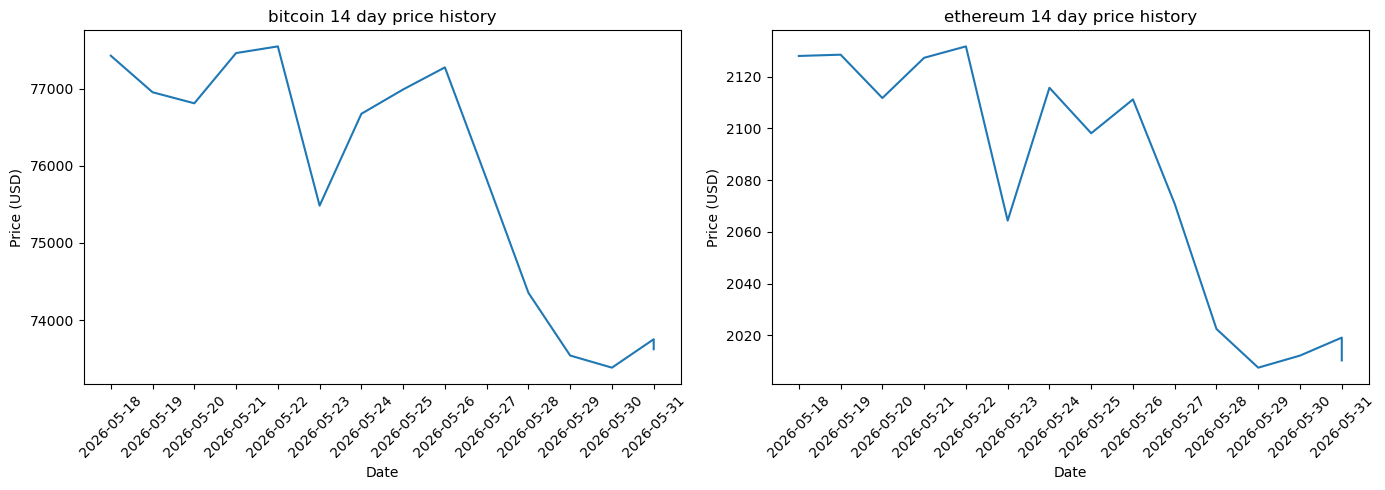

In [57]:
import matplotlib.pyplot as plt

bitcoin_df = all_coins_df[all_coins_df["coin_id"] == "bitcoin"]
ethereum_df = all_coins_df[all_coins_df["coin_id"] == "ethereum"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(bitcoin_df["date"], bitcoin_df["price"],)
ax1.set_title("bitcoin 14 day price history")
ax1.set_xlabel("Date")
ax1.set_ylabel("Price (USD)")
ax1.tick_params(axis='x', rotation=45)

ax2.plot(ethereum_df["date"], ethereum_df["price"],)
ax2.set_title("ethereum 14 day price history")
ax2.set_xlabel("Date")
ax2.set_ylabel("Price (USD)")
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [59]:
#Extract last day for bitcoin and ethereum
latest_api = all_coins_df[all_coins_df["coin_id"].isin(["bitcoin", "ethereum"])]
latest_api = latest_api.groupby("coin_id").last().reset_index()
latest_api = latest_api[["coin_id", "date", "price"]]

#adjust scraped_df for merging
scraped_merge = scraped_df[scraped_df["name"].isin(["Bitcoin", "Ethereum"])].copy()
scraped_merge["coin_id"] = scraped_merge["name"].str.lower()

#Merge
merged = latest_api.merge(scraped_merge[["coin_id", "price"]], on="coin_id", suffixes=("_api", "_scraped"))

#Calculate difference
merged["price_diff"] = abs(merged["price_api"] - merged["price_scraped"])
print(merged[["coin_id", "price_api", "price_scraped", "price_diff"]])

    coin_id     price_api  price_scraped  price_diff
0   bitcoin  73621.380247       73553.44   67.940247
1  ethereum   2010.362204        2008.42    1.942204


In [60]:
btc_data = all_coins_df[all_coins_df["coin_id"] == "bitcoin"].sort_values("date")

latest_price = btc_data["price"].iloc[-1]
price_7days_ago = btc_data["price"].iloc[-8]

calculated_change = ((latest_price - price_7days_ago) / price_7days_ago) * 100

scraped = scraped_df[scraped_df["name"] == "Bitcoin"]["7d_change"].values[0]

print(f"Calculated 7d change: {calculated_change:.2f}%")
print(f"Scraped 7d change: {scraped:.2f}%")

Calculated 7d change: -4.37%
Scraped 7d change: 3.62%
